# Testing class implementation

`15/09/2026`

Classes implemented in their respective modules. This notebook aims to hone
in on the API and check numerics of the calculations performed.

In [5]:
import numpy as np
import matplotlib.pyplot as plt

## 1. The potential:

In [6]:
from emerald.potentials import MorseSoftCoulomb

msc = MorseSoftCoulomb(alpha=0.5)

Well depth: 2.0
return points for E = -0.5, r_m = -0.44, r_M = 1.94


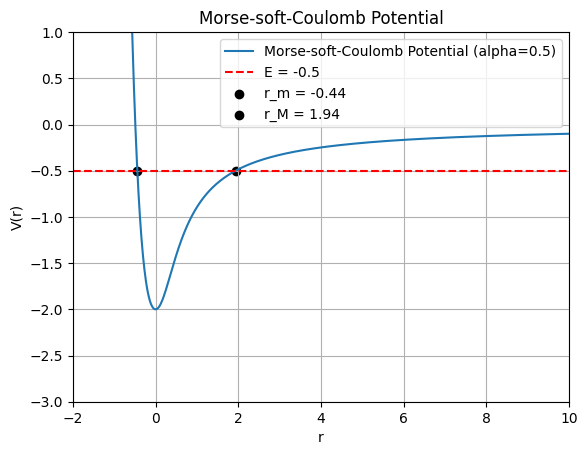

In [7]:
print(f"Well depth: {msc.well_depth}")
E = -0.5

rm, rM = msc.return_points(E)

print(f"return points for E = {E}, r_m = {rm:.2f}, r_M = {rM:.2f}")

r_grid = np.linspace(-2, 10, 1000)

plt.plot(r_grid, msc(r_grid), label=f"{msc.name} Potential (alpha={msc.alpha})")
plt.xlabel("r")
plt.ylabel("V(r)")
plt.axhline(E, color='r', linestyle='--', label=f"E = {E}")
plt.scatter(rm, msc(rm), color='black', label=f"r_m = {rm:.2f}")
plt.scatter(rM, msc(rM), color='black', label=f"r_M = {rM:.2f}")
plt.legend()
plt.title(f"{msc.name} Potential")
plt.xlim(-2, 10)
plt.ylim(-3, 1)
plt.grid()

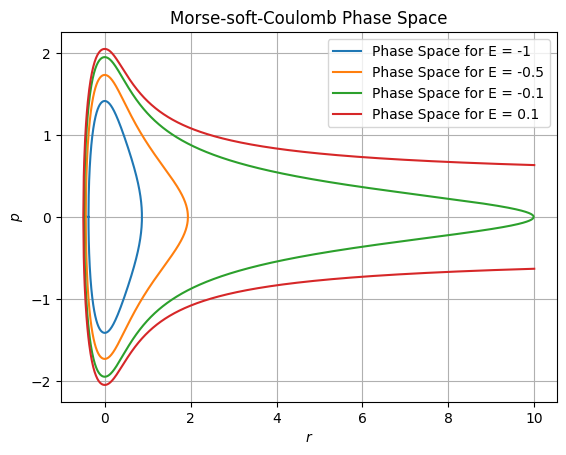

In [8]:
# What other methods does Potential have?

for _E in [-1, -0.5, -0.1, 0.1]:
    ps = msc.phase_space(_E, N=1000, r1=-1, r2 = 10)

    plt.plot(ps[0], ps[1], label=f"Phase Space for E = {_E}")
plt.xlabel("$r$")
plt.ylabel("$p$")
plt.legend()
plt.title(f"{msc.name} Phase Space")
plt.grid()

### 1.1 Action calculation

In [9]:
# Action and angle calculation, let's check the convergence of the numerics:

from emerald.classical.msc_unperturbed import MsC_action

act_class = msc.action(E, method="simpson")
act_num = MsC_action(msc.alpha, E)

print(f"Action for E = {E}: class = {act_class:.10f}, script = {act_num:.10f}")

# Improve parameters to find truth value

act_class = msc.action(E, dr=1.e-7, method="simpson")
act_num = MsC_action(msc.alpha, E, dr=1.e-7)

print(f"Action for E = {E}: class = {act_class:.10f}, script = {act_num:.10f}")
#script change in the tenth decimal place. Higher class result change


Action for E = -0.5: class = 0.7848602487, script = 0.7848683582
Action for E = -0.5: class = 0.7848602487, script = 0.7848683584


In [13]:
for dx in [1.e-5, 1.e-6, 1.e-7, 1.e-8]:
    act_num = MsC_action(msc.alpha, E, dr=dx)
    print(f"Number of points: N = {int((msc.return_points(E)[1] - msc.return_points(E)[0]) / dx)}")
    print(f"Action for E = {E}, dr={dx}: script = {act_num:.10f}")

Number of points: N = 237759
Action for E = -0.5, dr=1e-05: script = 0.7848683510
Number of points: N = 2377592
Action for E = -0.5, dr=1e-06: script = 0.7848683582
Number of points: N = 23775924
Action for E = -0.5, dr=1e-07: script = 0.7848683584
Number of points: N = 237759246
Action for E = -0.5, dr=1e-08: script = 0.7848683584


In [ ]:
for N in [1e3, 1e4, 1e5, 1e6]:
    act_class = msc.action(E, N=int(N), method="simpson")
    print(f"Action for E = {E}, N={int(N)}: script = {act_class:.10f}")

Action for E = -0.5, N=1000: script = 0.7848534580
Action for E = -0.5, N=10000: script = 0.7848678874
Action for E = -0.5, N=100000: script = 0.7848683435
Action for E = -0.5, N=1000000: script = 0.7848683579


In [ ]:
# timeit on class implementation



%timeit act_class = msc.action(E, dr=1.e-6, method="simpson")
%timeit act_num = MsC_action(msc.alpha, E, dr=1.e-6)


107 ms ± 1.93 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
17.8 ms ± 347 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [ ]:
%timeit act_class = msc.action(E, N=int(1e6), method="simpson")


57.6 ms ± 11.1 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [ ]:
# It looks like at 1e6 points the class implementation converges and isn't as slow

Es = np.linspace(-1, -0.01, 20)

for _E in Es:
    act_class = msc.action(_E, N=int(1e6), method="simpson")
    act_num = MsC_action(msc.alpha, _E, dr=1.e-8)
    print(f"Action for E = {_E:.2f}: class = {act_class:.10f}, script = {act_num:.10f}")
    delt = abs(act_class - act_num)
    print(f"Difference: {delt:.5e}")

Action for E = -1.00: class = 0.4009009062, script = 0.4009009064
Difference: 1.70456e-10
Action for E = -0.95: class = 0.4296339047, script = 0.4296339049
Difference: 1.92590e-10
Action for E = -0.90: class = 0.4599952856, script = 0.4599952859
Difference: 2.09227e-10
Action for E = -0.84: class = 0.4922383158, script = 0.4922383160
Difference: 2.24596e-10
Action for E = -0.79: class = 0.5266730653, script = 0.5266730655
Difference: 2.48276e-10
Action for E = -0.74: class = 0.5636841769, script = 0.5636841772
Difference: 2.87484e-10
Action for E = -0.69: class = 0.6037559067, script = 0.6037559070
Difference: 3.13457e-10
Action for E = -0.64: class = 0.6475082399, script = 0.6475082403
Difference: 3.46479e-10
Action for E = -0.58: class = 0.6957503906, script = 0.6957503910
Difference: 3.83761e-10
Action for E = -0.53: class = 0.7495625282, script = 0.7495625286
Difference: 4.33892e-10
Action for E = -0.48: class = 0.8104252192, script = 0.8104252197
Difference: 4.92268e-10
Action for

Okay, I'm ready to swear by the class implementation. It is more memory intensive if we choose
a tiny `dr`, but by using the number of intervals as the parameter we don't bloat the number
of evaluations as much. `N=1e6` is pretty good, reaching a maximum error of about `1.e-7`. 
Counter intuitively, "harder problems" (smaller $\alpha$) actually shrink the interval of 
integration and thus require less points (although momentum varies more abruptly there, so
I won't swear by this statement).

As a last check, let's compute action using the Gauss-Legendre quadrature:

In [ ]:
from emerald.numerics.quadrature import gauss_legendre_quadrature


def makeshift_action(E, N):
    rm, rM = msc.return_points(E)
    action = gauss_legendre_quadrature(lambda r: msc.momentum(E, r), rm, rM, N) / np.pi
    return action

act_num = MsC_action(msc.alpha, E, dr=1.e-8)
act_class = msc.action(E, N=int(1e6), method="simpson")

act_gauss = makeshift_action(E, N=1000)
print(f"Action for E = {E}: class = {act_class:.10f}, script = {act_num:.10f}, gauss = {act_gauss:.10f}")

# Oh my, we have a contender!

Action for E = -0.5: class = 0.7848683579, script = 0.7848683584, gauss = 0.7848683590


In [22]:
%timeit act_gauss = makeshift_action(E, N=1500)


72.1 ms ± 745 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [23]:
for _E in Es:
    act_gauss = makeshift_action(_E, N=1500)
    act_num = MsC_action(msc.alpha, _E, dr=1.e-8)
    print(f"Action for E = {_E:.2f}: gauss = {act_gauss:.10f}, script = {act_num:.10f}")
    delt = abs(act_gauss - act_num)
    print(f"Difference: {delt:.5e}")

Action for E = -1.00: gauss = 0.4009009065, script = 0.4009009064
Difference: 6.79197e-11
Action for E = -0.95: gauss = 0.4296339050, script = 0.4296339049
Difference: 7.37955e-11
Action for E = -0.90: gauss = 0.4599952859, script = 0.4599952859
Difference: 8.02646e-11
Action for E = -0.84: gauss = 0.4922383161, script = 0.4922383160
Difference: 8.75082e-11
Action for E = -0.79: gauss = 0.5266730656, script = 0.5266730655
Difference: 9.56114e-11
Action for E = -0.74: gauss = 0.5636841773, script = 0.5636841772
Difference: 1.05506e-10
Action for E = -0.69: gauss = 0.6037559071, script = 0.6037559070
Difference: 1.16337e-10
Action for E = -0.64: gauss = 0.6475082404, script = 0.6475082403
Difference: 1.29217e-10
Action for E = -0.58: gauss = 0.6957503911, script = 0.6957503910
Difference: 1.44588e-10
Action for E = -0.53: gauss = 0.7495625288, script = 0.7495625286
Difference: 1.63670e-10
Action for E = -0.48: gauss = 0.8104252199, script = 0.8104252197
Difference: 1.86967e-10
Action for

We can safely modify the implementation to use the Gauss-Legendre quadrature method with 1500 points.
This is equivalent to approximating the integrand by a 2999 degree polynomial!


In [ ]:
msc.action(E)
# Hurray!

0.7848683585953786

### 1.2 Angular frequency

